# Lab 06: CNN on CIFAR-10 (Ali Hamza)

**Course:** COMP-341L - Artificial Neural Networks Lab  
**Student:** Ali Hamza  
**Roll Number:** B23F0063AI106  
**Section:** B.S AI - Red  
**Execution Environment:** Google Colab only (no local installation on macOS)

This notebook implements all required tasks from Lab 06 (Tasks 1-8).

In [ ]:
# Optional: Mount Google Drive for persistent saving.
# Keep commented if you are not using Drive.
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from datetime import datetime

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

STUDENT_NAME = 'Ali Hamza'
ROLL_NUMBER = 'B23F0063AI106'
SECTION = 'B.S AI - Red'
EPOCHS = 10
BATCH_SIZE = 64

# Set this to a Google Drive path in Colab for persistent files.
# Example:
# BASE_DIR = '/content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab'
BASE_DIR = os.environ.get('LAB6_BASE_DIR', '.')
PLOTS_DIR = os.path.join(BASE_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

print('TensorFlow version:', tf.__version__)
print('BASE_DIR:', os.path.abspath(BASE_DIR))
print('PLOTS_DIR:', os.path.abspath(PLOTS_DIR))

TensorFlow version: 2.19.0
BASE_DIR: /content
PLOTS_DIR: /content/plots


## Task 1: Load and Explore the CIFAR-10 Dataset
- Display dataset shape
- Show at least 10 sample images
- Visualize class names

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000, 1)
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/tmp/ipython-input-2047/175424818.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(class_names[int(y_train[i])])


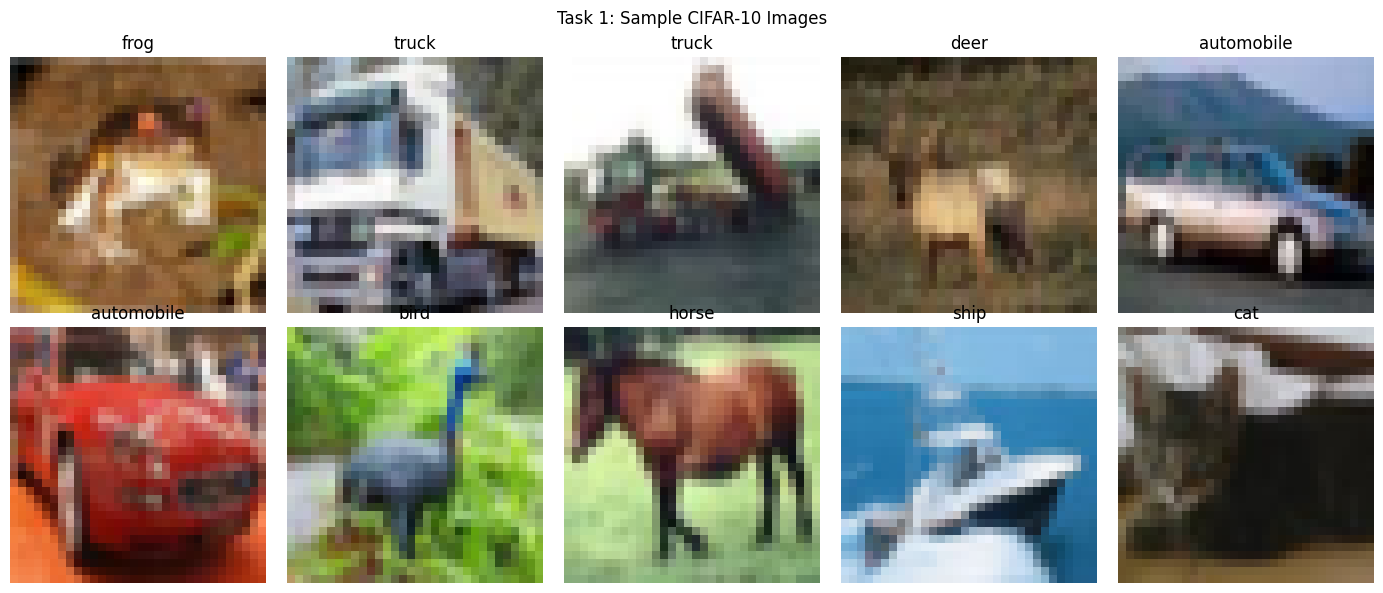

Saved: ./plots/task1_sample_images.png


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape :', x_test.shape)
print('y_test shape :', y_test.shape)
print('Class names:', class_names)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(y_train[i])])
    ax.axis('off')
plt.suptitle('Task 1: Sample CIFAR-10 Images')
plt.tight_layout()
sample_path = os.path.join(PLOTS_DIR, 'task1_sample_images.png')
plt.savefig(sample_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', sample_path)

## Task 2: Preprocess the Data
- Normalize pixel values
- Convert labels if required

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = y_train.squeeze().astype('int64')
y_test = y_test.squeeze().astype('int64')

print('After preprocessing:')
print('x_train min/max:', x_train.min(), x_train.max())
print('x_test min/max :', x_test.min(), x_test.max())
print('y_train shape  :', y_train.shape)
print('y_test shape   :', y_test.shape)
print('Using sparse labels with sparse_categorical_crossentropy, so one-hot encoding is optional here.')

After preprocessing:
x_train min/max: 0.0 1.0
x_test min/max : 0.0 1.0
y_train shape  : (50000,)
y_test shape   : (10000,)
Using sparse labels with sparse_categorical_crossentropy, so one-hot encoding is optional here.


## Task 3: Build a CNN Model
Requirements satisfied:
- At least 2 Conv layers
- ReLU activations
- MaxPooling
- Dropout
- Dense layers
- Softmax output

In [ ]:
def build_model(input_shape=(32, 32, 3), num_classes=10):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.30),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.50),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ], name='cifar10_cnn_ali')
    return model

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "cifar10_cnn_ali"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Train the CNN
- Train for at least 10 epochs
- Show training/validation accuracy and loss

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1,
)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f'Final Training Accuracy   : {final_train_acc:.4f}')
print(f'Final Validation Accuracy : {final_val_acc:.4f}')
print(f'Final Training Loss       : {final_train_loss:.4f}')
print(f'Final Validation Loss     : {final_val_loss:.4f}')

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 248s 352ms/step - accuracy: 0.3839 - loss: 1.6715 - val_accuracy: 0.5202 - val_loss: 1.3179
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 241s 342ms/step - accuracy: 0.5175 - loss: 1.3266 - val_accuracy: 0.6318 - val_loss: 1.0442
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 266s 348ms/step - accuracy: 0.5762 - loss: 1.1836 - val_accuracy: 0.6670 - val_loss: 0.9502
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 257s 341ms/step - accuracy: 0.6161 - loss: 1.0812 - val_accuracy: 0.6906 - val_loss: 0.8948
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 251s 356ms/step - accuracy: 0.6467 - loss: 1.0024 - val_accuracy: 0.7208 - val_loss: 0.8223
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 258s 367ms/step - accuracy: 0.6639 - loss: 0.9395 - val_accuracy: 0.7324 - val_loss: 0.7715
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 238s 338ms/step - accuracy: 0.6873 - loss: 0.8821 - val_accuracy: 0.7270 - val_loss: 0.8043
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 240s 341ms/step - accuracy: 0.6997 -

In [12]:
# Set persistent output location (Google Drive in Colab).
import os

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    BASE_DIR = "/content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab"
else:
    # Local/Jupyter fallback
    BASE_DIR = "."

PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

print("IN_COLAB:", IN_COLAB)
print("BASE_DIR:", os.path.abspath(BASE_DIR))
print("PLOTS_DIR:", os.path.abspath(PLOTS_DIR))


Mounted at /content/drive
IN_COLAB: True
BASE_DIR: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab
PLOTS_DIR: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots


## Task 5: Evaluate the Model
- Compute test accuracy
- Show confusion matrix
- Display classification report

Test Accuracy: 0.7285
Test Loss    : 0.7774


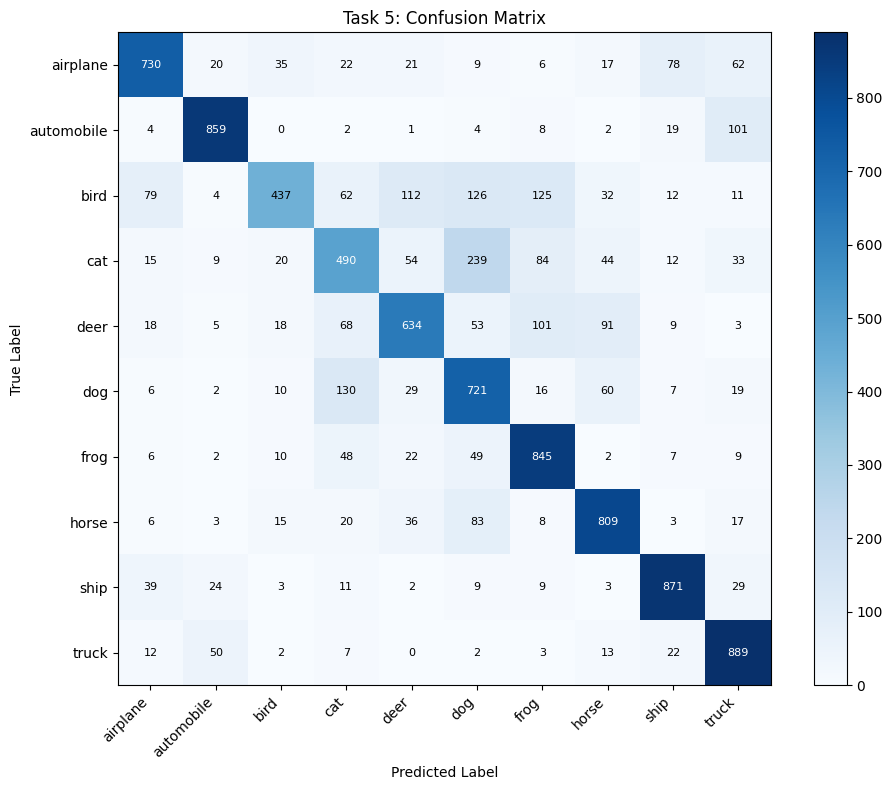

Saved: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots/task5_confusion_matrix.png
Classification Report:
              precision    recall  f1-score   support

    airplane     0.7978    0.7300    0.7624      1000
  automobile     0.8783    0.8590    0.8686      1000
        bird     0.7945    0.4370    0.5639      1000
         cat     0.5698    0.4900    0.5269      1000
        deer     0.6959    0.6340    0.6635      1000
         dog     0.5568    0.7210    0.6283      1000
        frog     0.7012    0.8450    0.7664      1000
       horse     0.7540    0.8090    0.7805      1000
        ship     0.8375    0.8710    0.8539      1000
       truck     0.7579    0.8890    0.8182      1000

    accuracy                         0.7285     10000
   macro avg     0.7344    0.7285    0.7233     10000
weighted avg     0.7344    0.7285    0.7233     10000

Saved: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots/task5_classification_report.txt


In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss    : {test_loss:.4f}')

y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set_title('Task 5: Confusion Matrix')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black', fontsize=8)
plt.tight_layout()
cm_path = os.path.join(PLOTS_DIR, 'task5_confusion_matrix.png')
plt.savefig(cm_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', cm_path)

report_text = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print('Classification Report:')
print(report_text)

report_path = os.path.join(PLOTS_DIR, 'task5_classification_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)
print('Saved:', report_path)

## Task 6: Make Predictions
- Pick 5 random CIFAR-10 test images
- Show actual and predicted labels

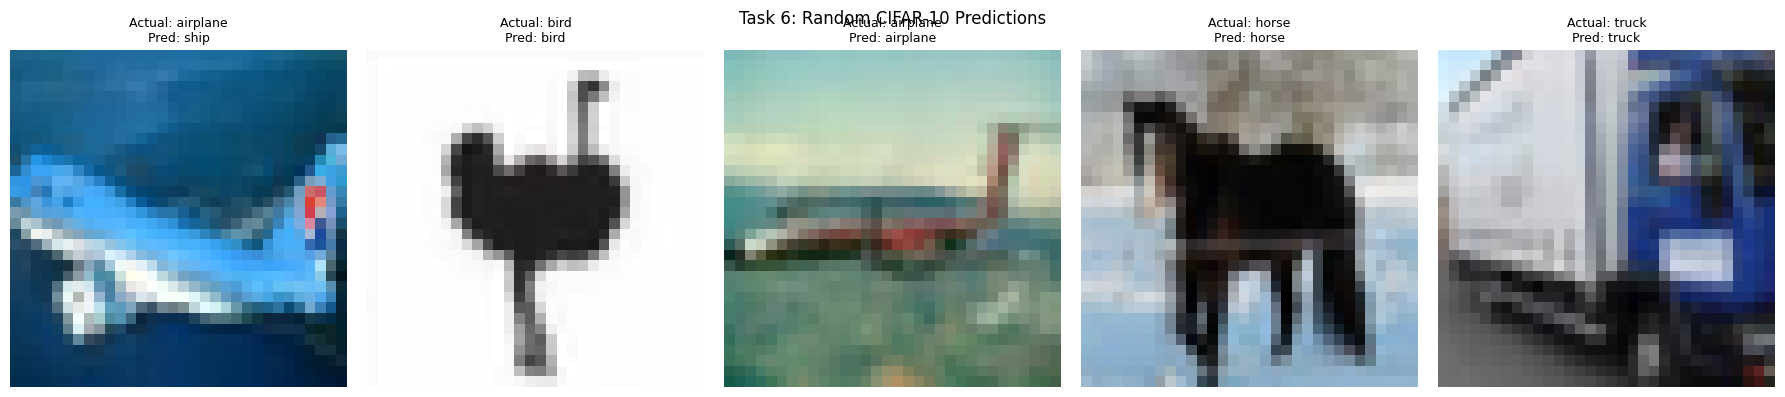

Saved: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots/task6_random_predictions.png


In [14]:
rng = np.random.default_rng(SEED)
indices = rng.choice(len(x_test), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, idx in zip(axes, indices):
    ax.imshow(x_test[idx])
    actual = class_names[int(y_test[idx])]
    pred = class_names[int(y_pred[idx])]
    ax.set_title(f'Actual: {actual}\nPred: {pred}', fontsize=9)
    ax.axis('off')

plt.suptitle('Task 6: Random CIFAR-10 Predictions')
plt.tight_layout()
pred_path = os.path.join(PLOTS_DIR, 'task6_random_predictions.png')
plt.savefig(pred_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', pred_path)

## Task 7: Plot Results
- Training vs validation accuracy
- Training vs validation loss

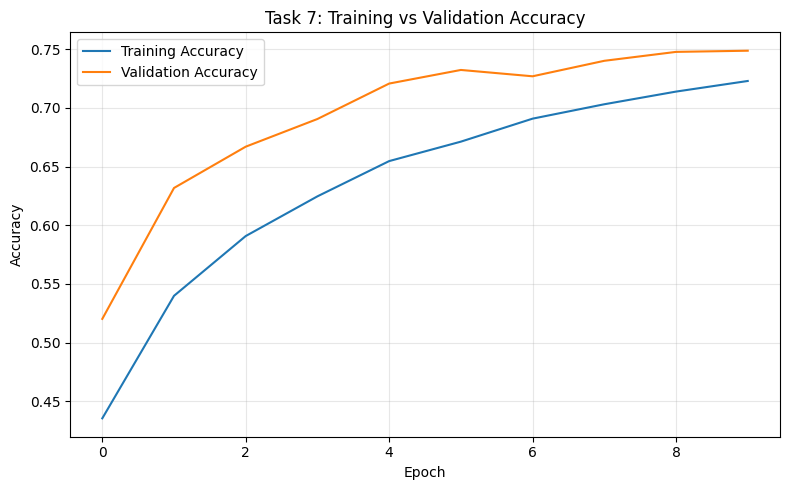

Saved: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots/task7_accuracy_curve.png


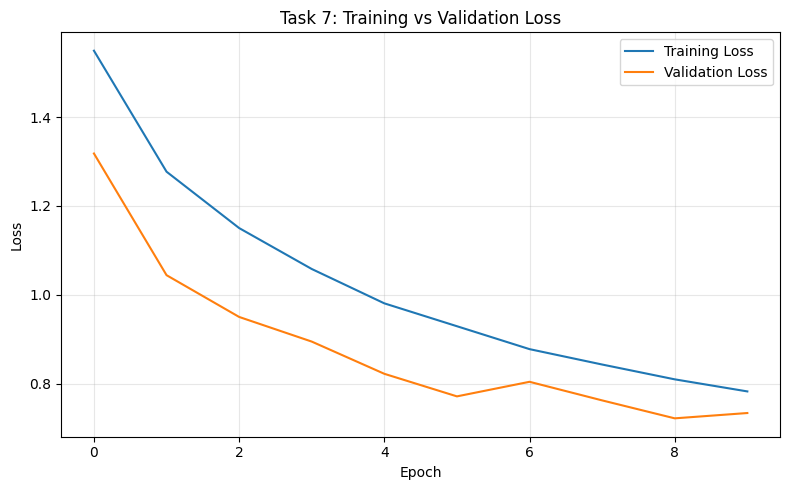

Saved: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots/task7_loss_curve.png


In [15]:
# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Task 7: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()
acc_path = os.path.join(PLOTS_DIR, 'task7_accuracy_curve.png')
plt.tight_layout()
plt.savefig(acc_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', acc_path)

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Task 7: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()
loss_path = os.path.join(PLOTS_DIR, 'task7_loss_curve.png')
plt.tight_layout()
plt.savefig(loss_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', loss_path)

In [16]:
import os
print("BASE_DIR:", os.path.abspath(BASE_DIR))
print("PLOTS_DIR:", os.path.abspath(PLOTS_DIR))
print("PLOTS exists:", os.path.exists(PLOTS_DIR))


BASE_DIR: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab
PLOTS_DIR: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots
PLOTS exists: True


In [17]:
BASE_DIR = "/content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab"
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)
print(BASE_DIR, PLOTS_DIR)

/content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots


## Task 8: Provide Analysis
Short paragraph about:
- CNN performance
- Why accuracy is high/low
- Improvements

In [18]:
val_gap = final_train_acc - final_val_acc
if test_acc >= 0.70:
    performance_level = 'good'
elif test_acc >= 0.55:
    performance_level = 'moderate'
else:
    performance_level = 'low'

analysis_paragraph = (
    f"The CNN achieved {performance_level} performance on CIFAR-10 with test accuracy "
    f"of {test_acc:.4f} after {EPOCHS} epochs. "
    f"Training accuracy was {final_train_acc:.4f} and validation accuracy was {final_val_acc:.4f} "
    f"(gap={val_gap:.4f}), indicating {'limited overfitting' if val_gap < 0.08 else 'noticeable overfitting'}. "
    f"CIFAR-10 contains complex natural images, so moderate accuracy is expected with short training. "
    f"Performance can improve with stronger data augmentation, deeper CNN blocks, better learning-rate scheduling, "
    f"and longer training."
)

print(analysis_paragraph)

analysis_path = os.path.join(PLOTS_DIR, 'task8_analysis.txt')
with open(analysis_path, 'w', encoding='utf-8') as f:
    f.write(analysis_paragraph + '\n')
print('Saved:', analysis_path)


The CNN achieved good performance on CIFAR-10 with test accuracy of 0.7285 after 10 epochs. Training accuracy was 0.7230 and validation accuracy was 0.7488 (gap=-0.0258), indicating limited overfitting. CIFAR-10 contains complex natural images, so moderate accuracy is expected with short training. Performance can improve with stronger data augmentation, deeper CNN blocks, better learning-rate scheduling, and longer training.
Saved: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots/task8_analysis.txt


In [19]:
print('Current output directory:', os.path.abspath(BASE_DIR))
print('Current plots directory :', os.path.abspath(PLOTS_DIR))
print('Files in plots so far:')
for fn in sorted(os.listdir(PLOTS_DIR)):
    print(' -', fn)


Current output directory: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab
Current plots directory : /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/plots
Files in plots so far:
 - task5_classification_report.txt
 - task5_confusion_matrix.png
 - task6_random_predictions.png
 - task7_accuracy_curve.png
 - task7_loss_curve.png
 - task8_analysis.txt


## Generate `Lab_Report_6.md` and `Lab_Report_6.html`
Run the next cell after training/evaluation to export report files with your actual results.

In [20]:
import os
from datetime import datetime

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

report_md = f"""# Lab Report 6: Implementing a CNN on CIFAR-10

---

**Course Code:** COMP-341L  
**Course Name:** Artificial Neural Networks Lab  
**Lab Number:** 6  
**Lab Title:** Implementing Convolutional Neural Networks (CNN) for Image Classification  
**Date:** {datetime.now().strftime('%B %d, %Y')}  
**Name:** Ali Hamza  
**Roll Number:** B23F0063AI106  
**Section:** B.S AI - Red

---

## Objective
Implement and evaluate a CNN on CIFAR-10 by completing all required tasks: dataset exploration, preprocessing, CNN design, training, evaluation, prediction, visualization, and analysis.

## Task 1: Load and Explore the CIFAR-10 Dataset
- Displayed training and test dataset shapes.
- Visualized class names.
- Displayed 10 sample CIFAR-10 images.

![Task 1 Sample Images](plots/task1_sample_images.png)

## Task 2: Preprocess the Data
- Normalized pixel values to the [0, 1] range.
- Used sparse integer labels with `sparse_categorical_crossentropy`.

## Task 3: Build a CNN Model
The model includes convolution layers, ReLU activation, max-pooling, dropout, dense layers, and a softmax output layer.

## Task 4: Train the CNN (10 Epochs)
- Final training accuracy: {final_train_acc:.4f}
- Final validation accuracy: {final_val_acc:.4f}
- Final training loss: {final_train_loss:.4f}
- Final validation loss: {final_val_loss:.4f}

## Task 5: Evaluate the Model
- Test accuracy: {test_acc:.4f}
- Test loss: {test_loss:.4f}

![Confusion Matrix](plots/task5_confusion_matrix.png)

### Classification Report
```text
{report_text}
```

## Task 6: Make Predictions
Displayed 5 random test images with actual and predicted labels.

![Random Predictions](plots/task6_random_predictions.png)

## Task 7: Plot Results
![Training vs Validation Accuracy](plots/task7_accuracy_curve.png)
![Training vs Validation Loss](plots/task7_loss_curve.png)

## Task 8: Analysis
{analysis_paragraph}

## Conclusion
The required Lab 06 workflow was implemented successfully in Google Colab. The model was trained, evaluated, and analyzed using standard metrics and visual diagnostics.
"""

report_html_template = """<!doctype html>
<html lang='en'>
<head>
  <meta charset='utf-8'>
  <title>Lab Report 6 - Ali Hamza</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 28px; line-height: 1.5; color: #111; }}
    h1, h2, h3 {{ margin-top: 24px; }}
    img {{ max-width: 900px; width: 100%; border: 1px solid #ddd; margin: 8px 0 18px; }}
    pre {{ background: #f4f4f4; padding: 12px; overflow-x: auto; white-space: pre-wrap; }}
    .meta {{ margin: 0 0 12px; }}
  </style>
</head>
<body>
  <h1>Lab Report 6: Implementing a CNN on CIFAR-10</h1>
  <p class='meta'><strong>Course Code:</strong> COMP-341L<br>
  <strong>Course Name:</strong> Artificial Neural Networks Lab<br>
  <strong>Lab Number:</strong> 6<br>
  <strong>Date:</strong> __DATE__<br>
  <strong>Name:</strong> Ali Hamza<br>
  <strong>Roll Number:</strong> B23F0063AI106<br>
  <strong>Section:</strong> B.S AI - Red</p>

  <h2>Objective</h2>
  <p>Implement and evaluate a CNN on CIFAR-10 by completing all required tasks from the manual.</p>

  <h2>Task 1: Load and Explore</h2>
  <img src='plots/task1_sample_images.png' alt='Task 1 sample images'>

  <h2>Task 2: Preprocess</h2>
  <p>Images normalized to [0, 1]. Labels stored as sparse integer classes for sparse categorical loss.</p>

  <h2>Task 3: CNN Model</h2>
  <p>Architecture includes convolution, ReLU, max-pooling, dropout, dense, and softmax output layers.</p>

  <h2>Task 4: Training</h2>
  <ul>
    <li>Final training accuracy: __FINAL_TRAIN_ACC__</li>
    <li>Final validation accuracy: __FINAL_VAL_ACC__</li>
    <li>Final training loss: __FINAL_TRAIN_LOSS__</li>
    <li>Final validation loss: __FINAL_VAL_LOSS__</li>
  </ul>

  <h2>Task 5: Evaluation</h2>
  <p>Test accuracy: __TEST_ACC__<br>Test loss: __TEST_LOSS__</p>
  <img src='plots/task5_confusion_matrix.png' alt='Confusion matrix'>
  <h3>Classification Report</h3>
  <pre>__REPORT_TEXT__</pre>

  <h2>Task 6: Predictions</h2>
  <img src='plots/task6_random_predictions.png' alt='Random predictions'>

  <h2>Task 7: Plots</h2>
  <img src='plots/task7_accuracy_curve.png' alt='Accuracy curve'>
  <img src='plots/task7_loss_curve.png' alt='Loss curve'>

  <h2>Task 8: Analysis</h2>
  <p>__ANALYSIS__</p>

  <h2>Conclusion</h2>
  <p>The required Lab 06 workflow was implemented and evaluated with standard classification metrics and plots.</p>
</body>
</html>
"""

report_html = (
    report_html_template
    .replace('__DATE__', datetime.now().strftime('%B %d, %Y'))
    .replace('__FINAL_TRAIN_ACC__', f"{final_train_acc:.4f}")
    .replace('__FINAL_VAL_ACC__', f"{final_val_acc:.4f}")
    .replace('__FINAL_TRAIN_LOSS__', f"{final_train_loss:.4f}")
    .replace('__FINAL_VAL_LOSS__', f"{final_val_loss:.4f}")
    .replace('__TEST_ACC__', f"{test_acc:.4f}")
    .replace('__TEST_LOSS__', f"{test_loss:.4f}")
    .replace('__REPORT_TEXT__', report_text)
    .replace('__ANALYSIS__', analysis_paragraph)
)

md_path = os.path.join(BASE_DIR, 'Lab_Report_6.md')
html_path = os.path.join(BASE_DIR, 'Lab_Report_6.html')

with open(md_path, 'w', encoding='utf-8') as f:
    f.write(report_md)
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(report_html)

print('Saved:', os.path.abspath(md_path))
print('Saved:', os.path.abspath(html_path))
print('Plots currently saved in:')
for fn in sorted(os.listdir(PLOTS_DIR)):
    print(' -', fn)


Saved: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/Lab_Report_6.md
Saved: /content/drive/MyDrive/COMP-341L/Lab 6/Ali Hamza's Lab/Lab_Report_6.html
Plots currently saved in:
 - task5_classification_report.txt
 - task5_confusion_matrix.png
 - task6_random_predictions.png
 - task7_accuracy_curve.png
 - task7_loss_curve.png
 - task8_analysis.txt


In [21]:
# Optional: Zip deliverables for download from Colab.
# import shutil
# shutil.make_archive('Lab_6_Deliverables', 'zip', BASE_DIR)
# print('Created Lab_6_Deliverables.zip')